In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [3]:
df["Weather"]=np.where(df["Weather"]=="Sunny",2,np.where(df["Weather"]=="Cloudy",1,0))
df["Temperature"]=np.where(df["Temperature"]=="Hot",2,np.where(df["Temperature"]=="mild",1,0))
df["Humidity"]=np.where(df["Humidity"]=="High",1,0)
df["Wind"]=np.where(df["Wind"]=="Weak",0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,2,1,0,No
1,Day 2,2,2,1,1,No
2,Day 3,1,2,1,0,Yes
3,Day 4,0,0,1,0,Yes
4,Day 5,0,0,0,0,Yes
5,Day 6,0,0,0,1,No
6,Day 7,1,0,0,1,Yes
7,Day 8,2,0,1,0,No
8,Day 9,2,0,0,0,Yes
9,Day 10,0,0,0,0,Yes


In [4]:
x=df[["Weather","Temperature","Humidity","Wind"]]
y=df["Play_Sports?"]
print(x.shape)
print(y.shape)

(14, 4)
(14,)


In [8]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

diff=pd.DataFrame({"Actual Data":y,"Predicted Data":prediction})
diff

['No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'No']


,Actual Data,Predicted Data
0,No,No
1,No,No
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,No,No
6,Yes,Yes
7,No,No
8,Yes,Yes
9,Yes,Yes


In [9]:
dtree.get_depth()

4

In [10]:
from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=["Weather","Temperature","Humidity","Wind"])
print(text_representation)

|--- Humidity <= 0.50
|   |--- Wind <= 0.50
|   |   |--- class: Yes
|   |--- Wind >  0.50
|   |   |--- Weather <= 0.50
|   |   |   |--- class: No
|   |   |--- Weather >  0.50
|   |   |   |--- class: Yes
|--- Humidity >  0.50
|   |--- Weather <= 1.50
|   |   |--- Wind <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Wind >  0.50
|   |   |   |--- Weather <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Weather >  0.50
|   |   |   |   |--- class: Yes
|   |--- Weather >  1.50
|   |   |--- class: No



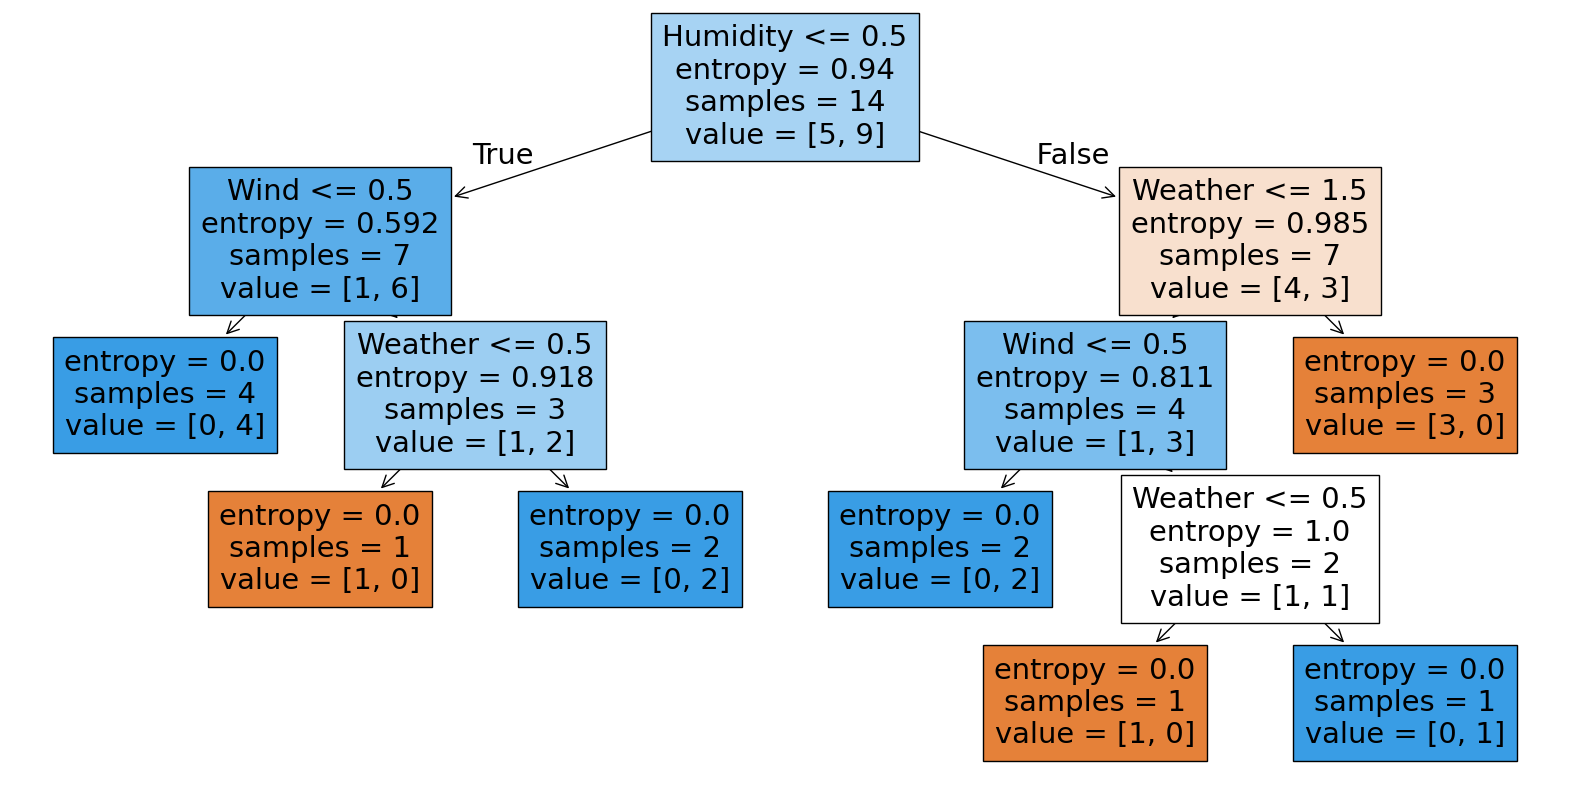

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()